# hHDAC8 Docking-Selective Inhibitor Generation Pipeline

End-to-end notebook: loads trained models, runs the docking-selective GA across all ZBG
lineages, assembles/gates/clusters the results, generates figures, and provides
`predict_from_smiles()` for scoring arbitrary compounds.

**Requirements before running:**
- `pipeline.py` and `ga.py` (updated versions from the tarball) in the same directory as this notebook, or on `sys.path`
- `run_state.pkl` (from `models/` in the original repo) in the same directory — contains the 6 pre-trained model bundles

**New vs. original notebook:** adds docking-score-based isoform selectivity as a Pareto
objective + directional threshold gate. HDAC8 docking target: ≤ -7 (strong). HDAC1/HDAC6
docking target: > -7 (weak). See Section 2 for details.


## 0. Setup

In [1]:
import sys, os, time, pickle, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem, DataStructs
from rdkit.ML.Cluster import Butina

# pipeline.py and ga.py must be in the same directory as this notebook
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', 'scripts'))

from pipeline import (descriptors_from_mol, compute_liability_flags, passes_tier1_gates,
                       is_hydroxamate, passes_lipinski_veber, morgan_fp, morgan_fp_bitvect,
                       max_training_similarity, AD_HARD_THRESHOLD, compute_zbg_precedent_counts,
                       ZBG_PRECEDENT_MIN, ic50_tier, rough_2d_l_shape_proxy, ZBG_TAGS,
                       SYNTHETIC_SEEDS, predict_batch)
from ga import (run_ga_pareto, passes_docking_selectivity_gate, passes_ic50_selectivity_gate,
                ZBG_PERIPHERY_ELIGIBLE, HDAC8_DOCK_MAX, OFFTARGET_DOCK_MIN, DOCK_AD_FLOOR,
                OFFTARGET_IC50_MIN_NM, MIN_SELECTIVITY_LOG)

# The GA, the assemble/gate/cluster/export step, and every constant they read come
# from run_docking_selective.py. The notebook used to carry its own copies, which
# meant a fix in the script (the empty-pool guards in assemble_and_export, for one)
# never reached the notebook. modes_to_run is imported for completeness; the
# notebook selects modes from RUN_MODE in ## 5 rather than from the script's
# RUN_ALL / RUN_BASELINE / RUN_SEPARATE_ZBG / RUN_INTEGRATED switches.
from run_docking_selective import (load_mode_run_state, save_mode_run_state,
                                   write_candidate_csvs, run_island, assemble_and_export,
                                   modes_to_run, zbg_of, full_tier1_ok, butina_cluster,
                                   quota_by_cell, RUN_STATE_PKL, MODES, CLUSTER_CUTOFF,
                                   MAX_IC50_NM, MAX_DOCKING_SCORE, GENERATIONS_PER_STAGE,
                                   POP_SIZE, MAX_HITS_PER_ISLAND, QUOTA_PER_CELL, QUOTA_REPS,
                                   ALL_LINEAGES, RANDOM_SEED, PERIPHERY_MUTATION_PROB)

print("All imports OK")
print(f"Docking gate: HDAC8 <= {HDAC8_DOCK_MAX} (strong), HDAC1/HDAC6 > {OFFTARGET_DOCK_MIN} (weak), AD floor {DOCK_AD_FLOOR}")
print(f"IC50 selectivity flag: off-target IC50 >= {OFFTARGET_IC50_MIN_NM} nM and >= {MIN_SELECTIVITY_LOG} log margin")


All imports OK
Docking gate: HDAC8 <= -7.0 (strong), HDAC1/HDAC6 > -7.0 (weak), AD floor -13.0
IC50 selectivity flag: off-target IC50 >= 1000.0 nM and >= 0.7 log margin


## 1. Load trained models

### (Optional) Retrain all six models from scratch

The shipped `run_state.pkl` already contains trained models, so **you can skip this cell** and just load them below. Run this **only** if you want to regenerate the models from the CSVs in `../data/` (e.g. after adding data). It retrains all six (HDAC8/1/6 IC50 + HDAC8/1/6 docking) with scaffold-grouped 5-fold CV and overwrites `../models/run_state.pkl`. Takes a few minutes on 1 CPU.

Set `RETRAIN = True` to run it.

In [2]:
RETRAIN = True   # set True to retrain all six models from ../data/ and rebuild run_state.pkl

if RETRAIN:
    import subprocess, sys as _sys
    # train_all_models.py lives in ../scripts (already on sys.path); call it as a module
    from train_all_models import main as _train_main
    _sys.argv = ['train_all_models.py', '--data-dir', os.path.join('..', 'data'),
                 '--out', os.path.join('..', 'models', 'run_state.pkl')]
    _train_main()
    print("Retrained and rebuilt ../models/run_state.pkl")
else:
    print("Skipping retrain — using existing ../models/run_state.pkl")

Retraining all six models (scaffold-grouped 5-fold CV):
  [ic50_bundle] scaffold-CV R2 = 0.529 (+/- 0.034), n = 6198
  [dock_bundle] scaffold-CV R2 = 0.417 (+/- 0.038), n = 11036
  [hdac1_bundle] scaffold-CV R2 = 0.560 (+/- 0.059), n = 11566
  [hdac6_bundle] scaffold-CV R2 = 0.537 (+/- 0.021), n = 10369
  [hdac1_dock_bundle] scaffold-CV R2 = 0.190 (+/- 0.059), n = 946
  [hdac6_dock_bundle] scaffold-CV R2 = 0.225 (+/- 0.112), n = 1003

Summary (scaffold-CV R2):
  ic50_bundle        R2=0.529  n=6,198
  dock_bundle        R2=0.417  n=11,036
  hdac1_bundle       R2=0.560  n=11,566
  hdac6_bundle       R2=0.537  n=10,369
  hdac1_dock_bundle  R2=0.190  n=946
  hdac6_dock_bundle  R2=0.225  n=1,003

Saved ../models/run_state.pkl  (ic50_df: 6,198 HDAC8 IC50 rows)
Retrained and rebuilt ../models/run_state.pkl


In [3]:
with open(os.path.join('..', 'models', 'run_state.pkl'), 'rb') as f:
    st = pickle.load(f)

ic50_bundle   = st['ic50_bundle']
dock_bundle   = st['dock_bundle']
hdac1_bundle  = st['hdac1_bundle']
hdac6_bundle  = st['hdac6_bundle']
hdac1_dock_bundle = st['hdac1_dock_bundle']
hdac6_dock_bundle = st['hdac6_dock_bundle']
ic50_df       = st['ic50_df']

print(f"HDAC8 IC50 model:    CV R² = {ic50_bundle['cv_r2']:.3f}, train n = {len(ic50_bundle['train_fps'])}")
print(f"HDAC8 docking model: CV R² = {dock_bundle['cv_r2']:.3f}, train n = {len(dock_bundle['train_fps'])}")
print(f"HDAC1 IC50 model:    CV R² = {hdac1_bundle['cv_r2']:.3f}, train n = {len(hdac1_bundle['train_fps'])}")
print(f"HDAC6 IC50 model:    CV R² = {hdac6_bundle['cv_r2']:.3f}, train n = {len(hdac6_bundle['train_fps'])}")
print(f"HDAC1 docking model: CV R² = {hdac1_dock_bundle['cv_r2']:.3f}, train n = {len(hdac1_dock_bundle['train_fps'])}")
print(f"HDAC6 docking model: CV R² = {hdac6_dock_bundle['cv_r2']:.3f}, train n = {len(hdac6_dock_bundle['train_fps'])}")
print(f"\nHDAC8 IC50 training set: {len(ic50_df)} compounds")


HDAC8 IC50 model:    CV R² = 0.529, train n = 6198
HDAC8 docking model: CV R² = 0.417, train n = 11036
HDAC1 IC50 model:    CV R² = 0.560, train n = 11566
HDAC6 IC50 model:    CV R² = 0.537, train n = 10369
HDAC1 docking model: CV R² = 0.190, train n = 946
HDAC6 docking model: CV R² = 0.225, train n = 1003

HDAC8 IC50 training set: 6198 compounds


## 2. Docking + IC50 selectivity gate — what changed

**Docking gate (hard, defines a qualifying hit):**
- HDAC8 predicted docking must be **≤ -7** (strong on-target binding), and not below a -13 applicability-domain floor.
- HDAC1 and HDAC6 predicted docking must each be **> -7** (weak off-target binding).

This is a clean directional threshold per isoform — simpler and more interpretable than the earlier ±1.5 tolerance band.

**IC50 selectivity (reported + preferred, not a hard hit gate):**
- Off-target predicted IC50 ≥ 1000 nM and HDAC8 ≥ 0.7 log more potent than each off-target → `passes_ic50_selectivity` flag.
- This is **not** folded into the hard hit gate. It was tried as a hard gate and proved far too strict (HDAC8's own median training IC50 is ~920 nM, so requiring it to beat weak off-targets collapsed yield to ~1 hit/lineage). Instead the existing `selectivity` Pareto objective pushes the search toward IC50-selective molecules, and the flag is enforced only where a fully-selective subset is wanted.

**GA mechanics:** `evaluate_candidate()` computes `docking_selectivity = min(dock_HDAC1, dock_HDAC6) - dock_HDAC8` as a Pareto objective (maximized alongside pIC50 / HDAC8 dock / liability / IC50-selectivity), and sets `passes_dock_gate`. The gate is **not** a hard rejection inside the GA — that would freeze lineages whose seeds start outside the target region. It gates only what counts as a returned hit; the Pareto objective is what drives the population toward selectivity across generations.

## 3. Configuration

In [4]:
# GA parameters, the Butina cutoff, the export quotas, the seed, and the lineage
# list are all imported from run_docking_selective.py in ## 0, so the notebook and
# the script cannot search or export differently. Change them there, not here.
# SYNTHETIC_SEEDS comes from pipeline.py the same way.
print(f"GA: {GENERATIONS_PER_STAGE} generations x 2 stages, pop {POP_SIZE}, "
      f"cap {MAX_HITS_PER_ISLAND} hits per island")
print(f"Legacy hit bounds: IC50 <= {MAX_IC50_NM} nM, HDAC8 docking <= {MAX_DOCKING_SCORE}")
print(f"Export: Butina cutoff {CLUSTER_CUTOFF}, {QUOTA_PER_CELL} per (ZBG, tier), "
      f"{QUOTA_REPS} cluster reps per ZBG")
print(f"Seed {RANDOM_SEED}; integrated-mode periphery mutation prob {PERIPHERY_MUTATION_PROB}")
print(f"ZBG lineages to search: {ALL_LINEAGES}")


GA: 55 generations x 2 stages, pop 100, cap 60 hits per island
Legacy hit bounds: IC50 <= 500 nM, HDAC8 docking <= -7.0
Export: Butina cutoff 0.4, 3 per (ZBG, tier), 4 cluster reps per ZBG
Seed 42; integrated-mode periphery mutation prob 0.05
ZBG lineages to search: ['Salicylamide', 'Ortho-aminoanilide', 'Acylurea', '3-HPT', 'Carboxylate', 'Trifluoromethyl-ketone', 'Cyclic-thione', 'alpha-amino-amide']


## 4. Helper functions

In [5]:
# zbg_of, full_tier1_ok, butina_cluster, and quota_by_cell used to be redefined
# here. They are imported from run_docking_selective.py in ## 0 now, so the
# notebook and the script share one implementation of each.
non_hydrox = ic50_df[~ic50_df['is_hydroxamate']]
print(f"Non-hydroxamate training compounds: {len(non_hydrox)}")


Non-hydroxamate training compounds: 2078


## 5. Run the GA — one island per ZBG lineage

`RUN_MODE` picks which execution mode you're working with. **Leave it as `None` and the notebook chooses for you**: it loads whichever mode you ran most recently, by pickle modification time. Run `../scripts/run_docking_selective.py` with a mode enabled, then "Run All" here, and the notebook follows along without edits. Pin it to `'baseline'`, `'separate_zbg'`, or `'integrated'` only when you want a specific mode regardless of what ran last.

The modes mirror the `RUN_BASELINE` / `RUN_SEPARATE_ZBG` / `RUN_INTEGRATED` switches in the script:

- **baseline** — normal search. No ZBG-periphery mutation, identical to the pre-refactor pipeline.
- **separate_zbg** — periphery mutation only, crossover disabled, and only the lineages in `ZBG_PERIPHERY_ELIGIBLE` (the five ZBGs with real measured HDAC8 data) are searched.
- **integrated** — normal search with periphery mutation blended into the same population at `PERIPHERY_MUTATION_PROB`.
- **all** — regenerate-only. Sweeps all three modes in `MODES` order, exporting each one in full before moving to the next (~75 min, against ~25 min for a single mode). This is explicit opt-in: `REGENERATE = True` with `RUN_MODE = None` still runs `'baseline'` alone.

Every downstream cell (export, figures, run-state save) derives its paths from `RUN_MODE`, so the modes write to `../candidates/<mode>/` and `../figures/<mode>/` and never overwrite each other.

By default this cell **loads the already-computed hit pool** from `../models/docking_selective_run_state.pkl`, one shared file keyed by mode name rather than one file per mode, so "Run All" completes in seconds. Set `REGENERATE = True` to re-run the full two-stage island GA with that mode's settings. When regenerating with `RUN_MODE = None`, it defaults to `'baseline'`, since there is no completed run to infer intent from.

Regenerating now exports inside this cell, on every path. Each mode goes through the same block (run the islands, then `assemble_and_export`, then `make_all_figures`), whether one mode was pinned or all three are sweeping, so there is no second copy of the export logic to keep in sync. `assemble_and_export` writes the four CSVs and this mode's pickle slot itself, which makes the standalone save in `## 11` redundant after any regenerate; that cell skips itself and only runs on the `REGENERATE = False` path, where you may have adjusted a dataframe by hand and want it stored.

In [6]:
from make_figures import make_all_figures

REGENERATE = True   # set True to re-run the full GA (~25 min per mode); False loads cached hits

# Leave RUN_MODE as None and the notebook picks a mode for you:
#   loading (REGENERATE = False) -> whichever mode was saved most recently, so
#                                   running the script and then running this
#                                   notebook just works with no edits
#   generating (REGENERATE = True) -> 'baseline', since there is no completed run
#                                     to infer intent from
# Set it to 'baseline', 'separate_zbg', or 'integrated' to pin one mode, or to
# 'all' to regenerate every mode in MODES order back to back (~75 min).
RUN_MODE = 'all'

# RANDOM_SEED, PERIPHERY_MUTATION_PROB, ALL_LINEAGES and the GA parameters are
# imported from run_docking_selective.py in ## 0, not redefined here.

if RUN_MODE is not None and RUN_MODE != 'all' and RUN_MODE not in MODES:
    raise ValueError(f"RUN_MODE must be None, 'all', or one of {MODES}, got {RUN_MODE!r}")

if REGENERATE:
    modes_this_run = list(MODES) if RUN_MODE == 'all' else [RUN_MODE or 'baseline']
    if RUN_MODE is None:
        print(f"RUN_MODE not set and REGENERATE = True, defaulting to '{modes_this_run[0]}'.")
    print(f"Regenerating: {modes_this_run}")

    # One block per mode, used for a single pinned mode and for the 'all' sweep
    # alike: run the islands, then assemble/gate/cluster/export, then figures.
    # assemble_and_export writes this mode's four CSVs and its slot in the shared
    # pickle, so nothing downstream has to redo the export.
    results = {}
    for mode in modes_this_run:
        print("\n" + "=" * 70 + f"\n=== MODE: {mode.replace('_', ' ').upper()} ===\n" + "=" * 70)
        # Reseeded per mode, so each one is reproducible on its own regardless of
        # which other modes ran first or in what order.
        random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)
        t_start = time.time()

        if mode == 'separate_zbg':
            lineages = [lin for lin in ALL_LINEAGES if lin in ZBG_PERIPHERY_ELIGIBLE]
            crossover_prob = 0.0
            periphery_prob = lambda lin: 1.0
            print(f"Running periphery-only exploration for: {lineages}")
            print(f"Skipped (not ZBG-periphery-eligible): "
                  f"{[lin for lin in ALL_LINEAGES if lin not in ZBG_PERIPHERY_ELIGIBLE]}")
        elif mode == 'integrated':
            lineages, crossover_prob = ALL_LINEAGES, 0.5
            periphery_prob = lambda lin: (PERIPHERY_MUTATION_PROB
                                          if lin in ZBG_PERIPHERY_ELIGIBLE else 0.0)
        else:
            lineages, crossover_prob = ALL_LINEAGES, 0.5
            periphery_prob = lambda lin: 0.0

        all_hits = {lin: run_island(lin, non_hydrox, ic50_bundle, dock_bundle,
                                    hdac1_bundle, hdac6_bundle,
                                    hdac1_dock_bundle, hdac6_dock_bundle,
                                    crossover_prob=crossover_prob,
                                    periphery_mutation_prob=periphery_prob(lin))
                    for lin in lineages}

        cand_dir = os.path.join('..', 'candidates', mode)
        fig_dir = os.path.join('..', 'figures', mode)
        hits_df, balanced_m, reps_m, screen_m = assemble_and_export(
            all_hits, ic50_df, non_hydrox, ic50_bundle, dock_bundle,
            output_dir=cand_dir, mode=mode, t_start=t_start)
        if hits_df is None:
            # Nothing was written, so make_all_figures would fail reading the CSVs
            # back. Skip it and carry on to the next mode rather than aborting.
            print(f"[{mode}] nothing survived the gates: no CSVs, no figures, no pickle slot.")
            continue
        make_all_figures(cand_dir=cand_dir, models_dir=os.path.join('..', 'models'),
                         fig_dir=fig_dir)
        results[mode] = (hits_df, balanced_m, reps_m, screen_m)

    print("\n=== Regenerate summary ===")
    for mode in modes_this_run:
        if mode in results:
            print(f"  {mode}: {len(results[mode][0])} hits, "
                  f"{len(results[mode][1])} balanced, {len(results[mode][3])} final-screened "
                  f"-> ../candidates/{mode}, ../figures/{mode}")
        else:
            print(f"  {mode}: nothing exported")

    if not results:
        raise RuntimeError(
            "No mode produced any candidates, so the cells below have nothing to read. "
            "Check the island summaries above.")

    # Cells below work on one mode: the last one that actually exported.
    RUN_MODE = [m for m in modes_this_run if m in results][-1]
    full_df, balanced, reps, final_screen = results[RUN_MODE]
    _regenerated = True
    if len(modes_this_run) > 1:
        print(f"\nCells below use '{RUN_MODE}'. To inspect another mode, re-run with "
              f"REGENERATE = False and RUN_MODE pinned to it.")
else:
    # Read one mode's slot out of the shared run-state pickle. Only the four
    # result dataframes are stored there. The six model bundles are identical
    # across modes and come from run_state.pkl, loaded further up.
    if RUN_MODE == 'all':
        print("RUN_MODE = 'all' applies to regenerating only; loading the most "
              "recently saved mode instead.")
        RUN_MODE = None
    RUN_MODE, _cached = load_mode_run_state(RUN_MODE)
    full_df = _cached['hits_df'].copy()
    balanced = _cached.get('balanced')
    reps = _cached.get('reps')
    final_screen = _cached.get('final_screen')
    _regenerated = False
    print(f"[{RUN_MODE}] Loaded cached hit pool from {os.path.basename(RUN_STATE_PKL)}: "
          f"{len(full_df)} hits across {full_df['zbg_tag'].nunique()} ZBG lineages")
    print(full_df['zbg_tag'].value_counts())

    # candidates/ is gitignored, so a fresh checkout has the pickle but no CSVs,
    # and ## 8 reads the CSVs back to draw the figures. Rewrite them from the
    # cached dataframes through the same writer a fresh run uses.
    if any(df is None for df in (balanced, reps, final_screen)):
        print("Cached slot is missing balanced/reps/final_screen; skipping the CSV "
              "rewrite. Re-run with REGENERATE = True to rebuild this mode.")
    else:
        write_candidate_csvs(full_df, balanced, reps, final_screen,
                             os.path.join('..', 'candidates', RUN_MODE))
        print(f"Rewrote the four CSVs in ../candidates/{RUN_MODE} from the cached dataframes.")

# Everything downstream derives from RUN_MODE, so the three modes never read or
# write each other's folders.
CAND_DIR = os.path.join('..', 'candidates', RUN_MODE)
FIG_DIR = os.path.join('..', 'figures', RUN_MODE)
print(f"\nmode={RUN_MODE}  candidates={CAND_DIR}  figures={FIG_DIR}")


Regenerating: ['baseline', 'separate_zbg', 'integrated']

=== MODE: BASELINE ===

--- Island: Salicylamide (1 real seeds available, 2 used) ---
Gen  1: survived Tier-1=100  front-0=100  best pIC50=5.530  meeting-bounds-this-gen=0  elite-lineages={'Salicylamide': 30}
Gen  2: survived Tier-1= 56  front-0= 13  best pIC50=5.738  meeting-bounds-this-gen=0  elite-lineages={'Salicylamide': 30}
Gen  3: survived Tier-1= 85  front-0= 17  best pIC50=6.107  meeting-bounds-this-gen=0  elite-lineages={'Salicylamide': 30}
Gen  4: survived Tier-1= 70  front-0= 21  best pIC50=6.107  meeting-bounds-this-gen=0  elite-lineages={'Salicylamide': 30}
Gen  5: survived Tier-1= 74  front-0= 32  best pIC50=6.222  meeting-bounds-this-gen=0  elite-lineages={'Salicylamide': 30}
Gen  6: survived Tier-1= 86  front-0= 49  best pIC50=6.222  meeting-bounds-this-gen=0  elite-lineages={'Salicylamide': 30}
Gen  7: survived Tier-1= 80  front-0= 37  best pIC50=6.821  meeting-bounds-this-gen=0  elite-lineages={'Salicylamide':

## 8. Figures

All nine figures are generated by `make_figures.py` (in `../scripts`) directly from the exported candidate CSVs plus the model bundles, and written to `../figures/<RUN_MODE>/`. Regenerating them is a single call, so the notebook stays clean and the figures are reproducible from the run outputs alone. The model bundles come from `run_state.pkl`, which is shared across all three modes, so only the candidate data differs between mode folders.

After a regenerate, `## 5` has already written this mode's figures. This cell redraws them from the same CSVs and displays them inline, which costs a few seconds and changes nothing on disk.

[integrated] Wrote: ['fig1', 'fig2', 'fig3', 'fig4', 'fig5', 'fig6', 'fig7', 'fig8', 'fig9']


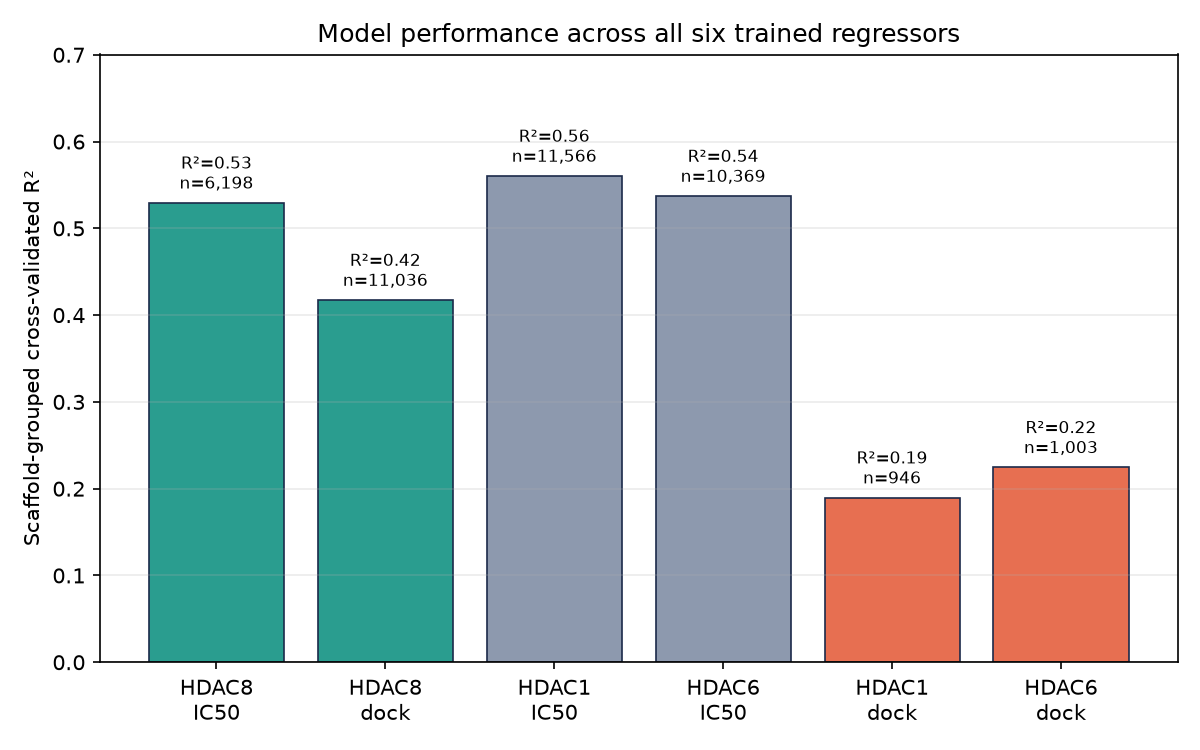

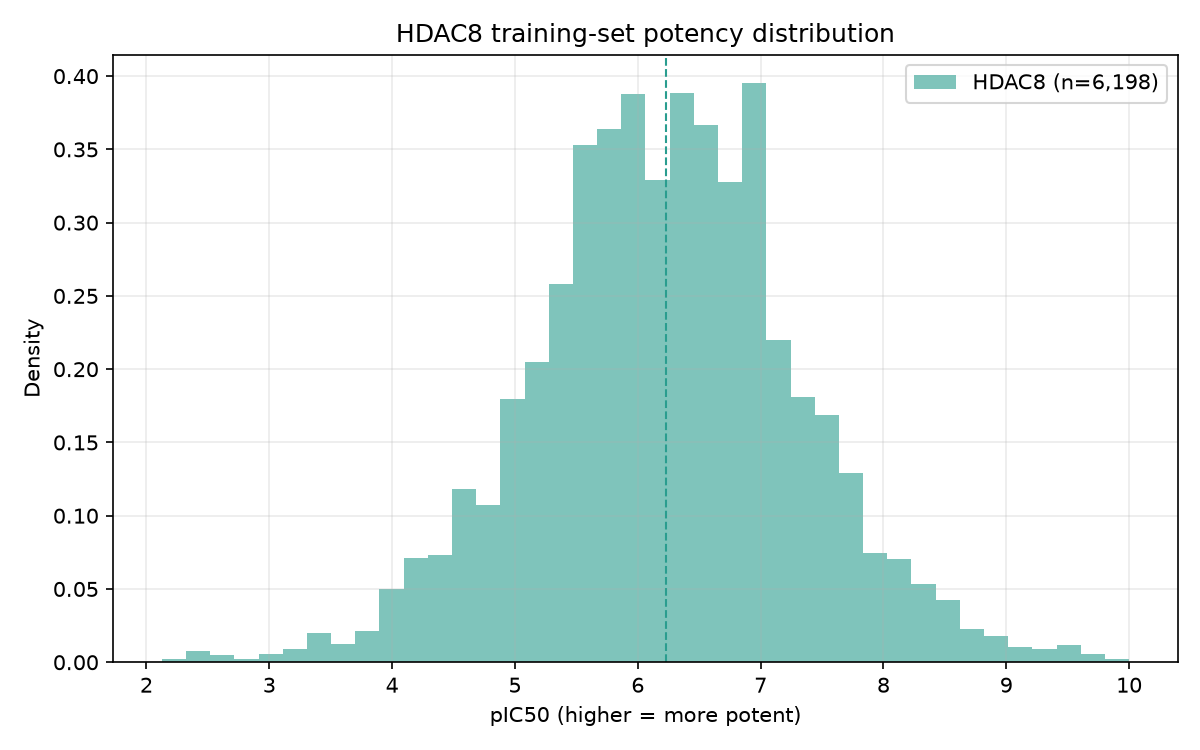

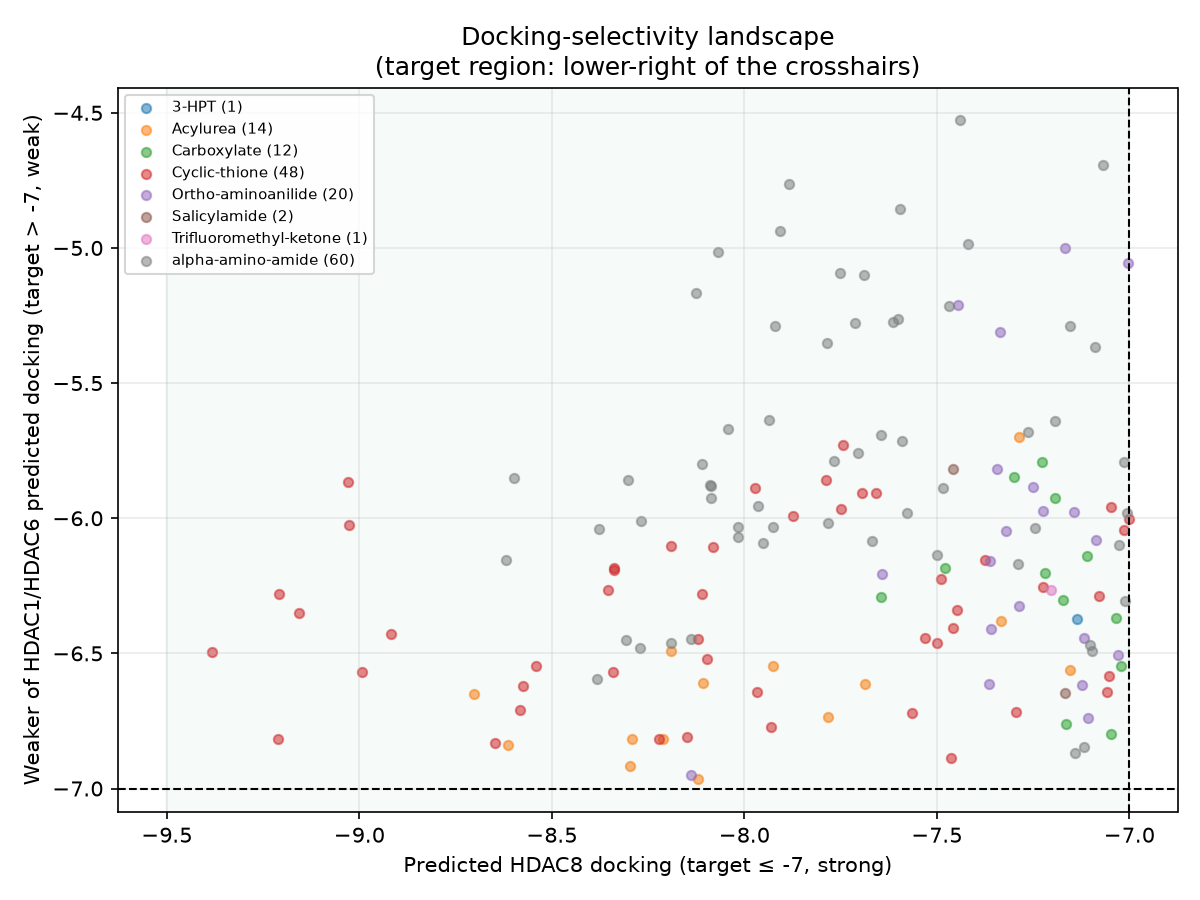

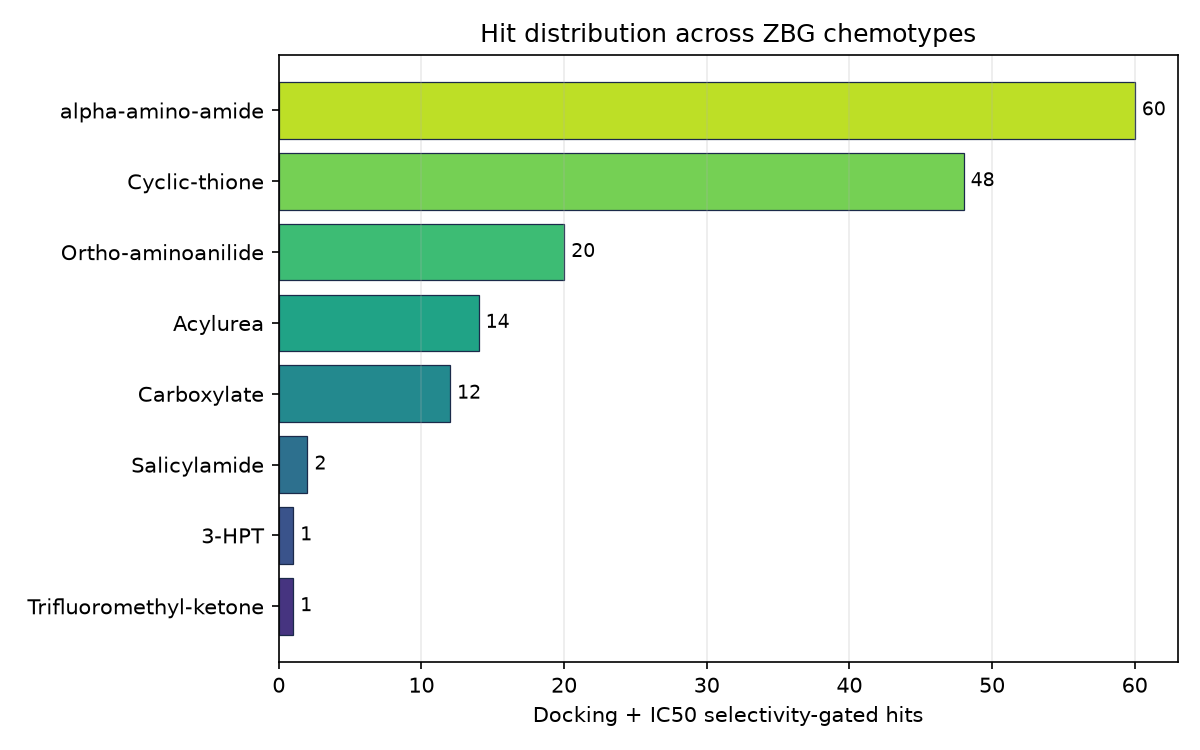

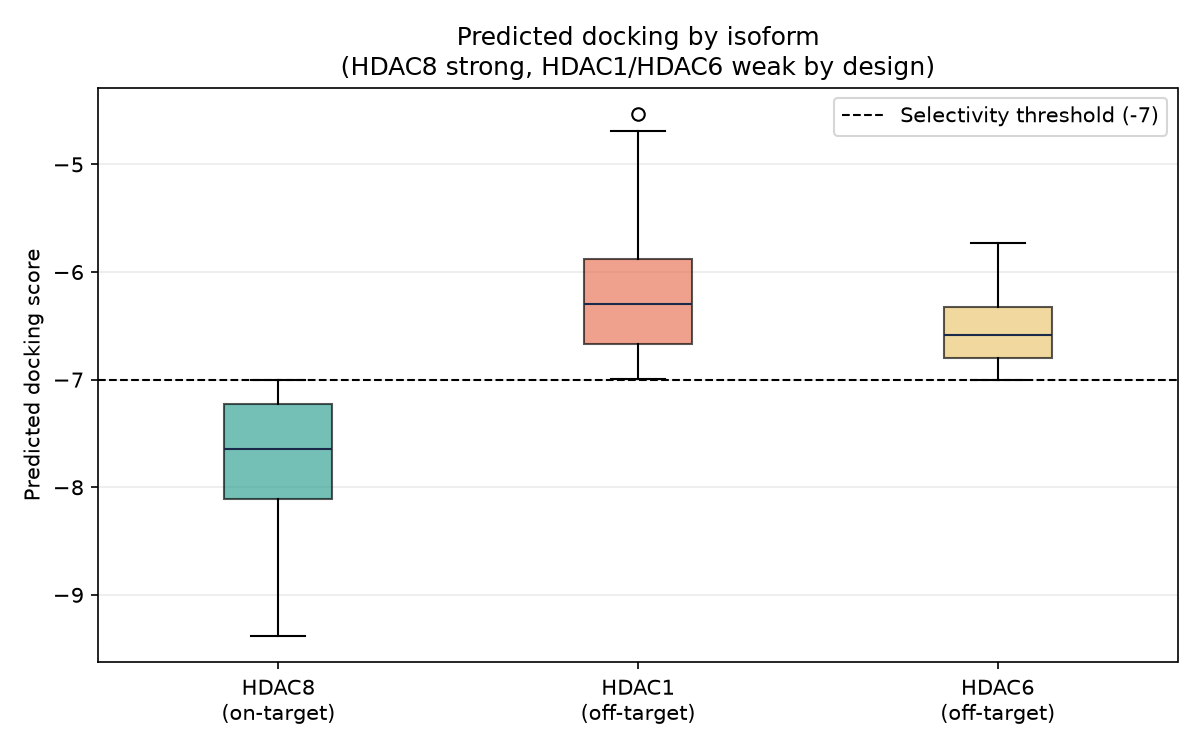

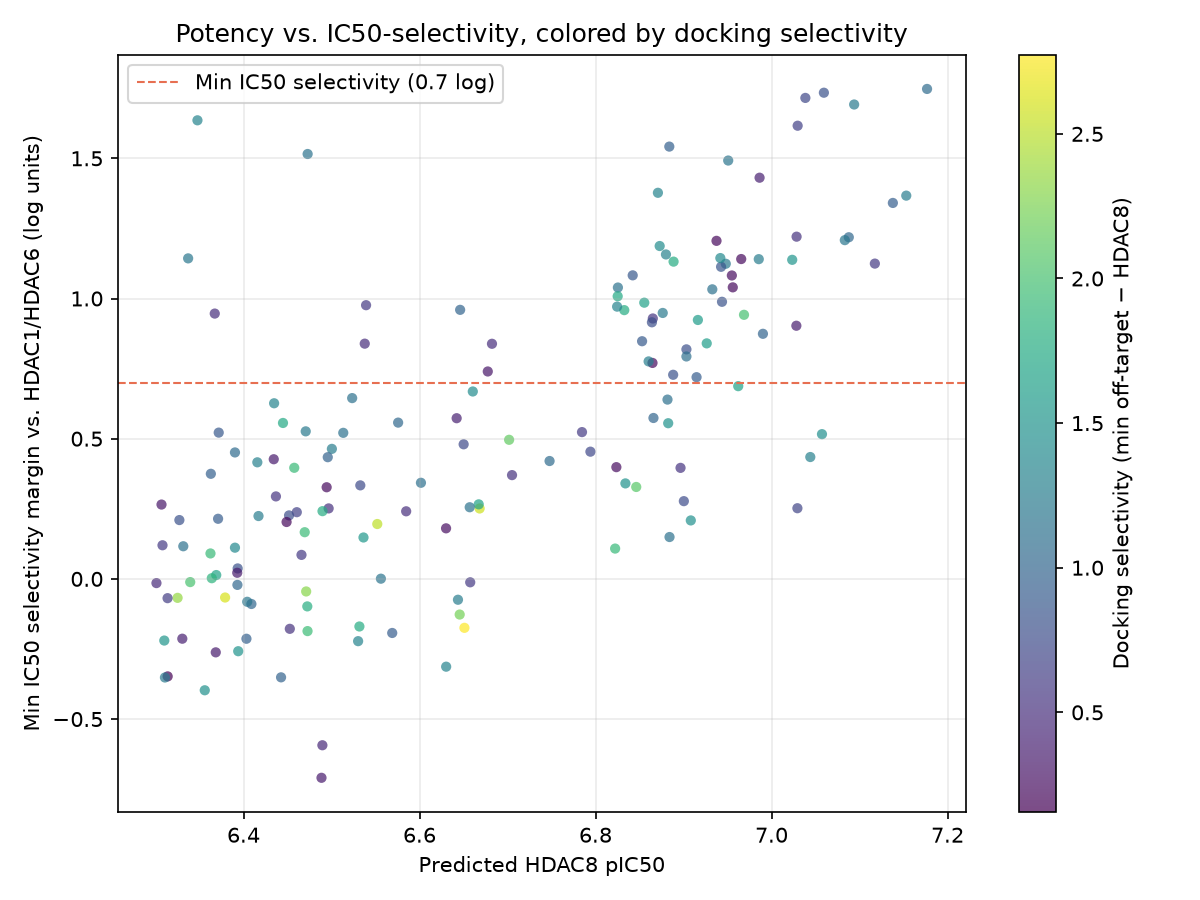

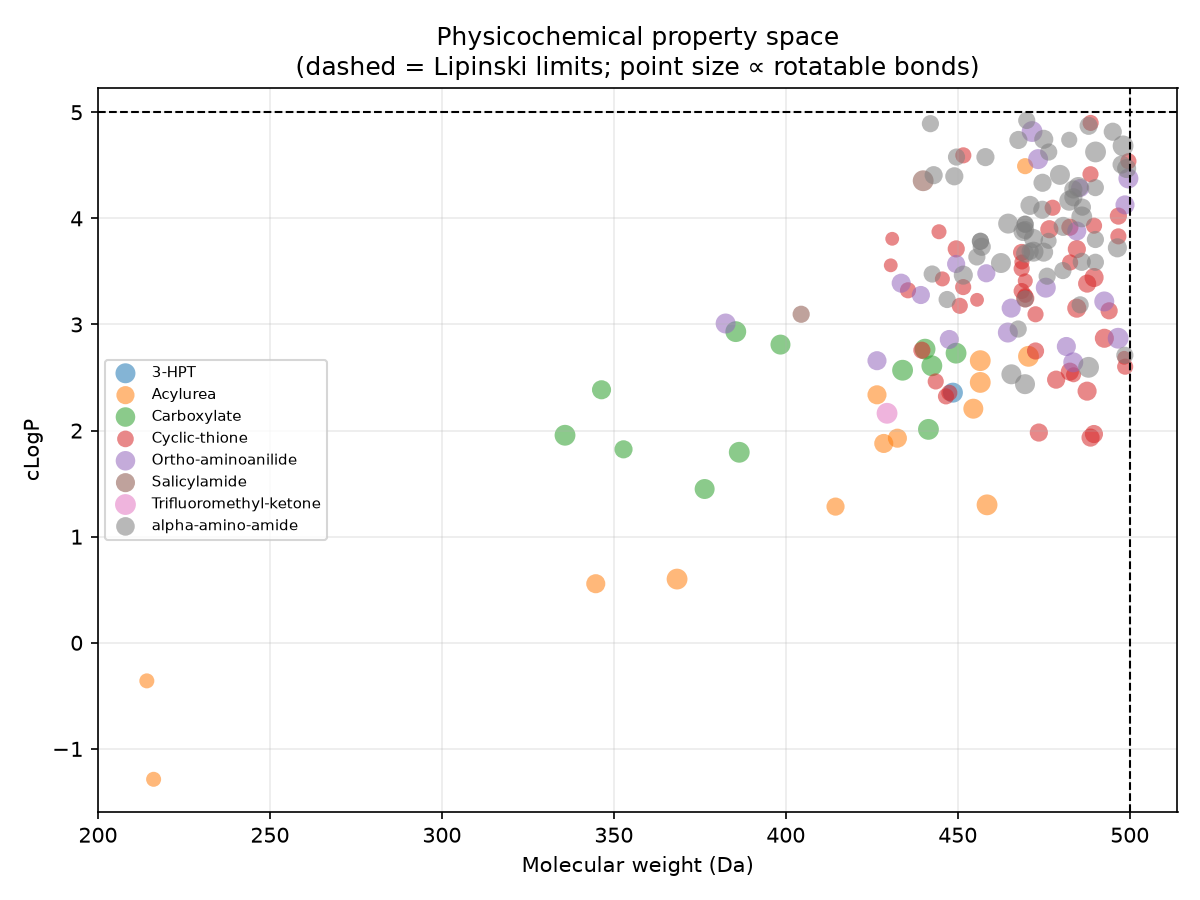

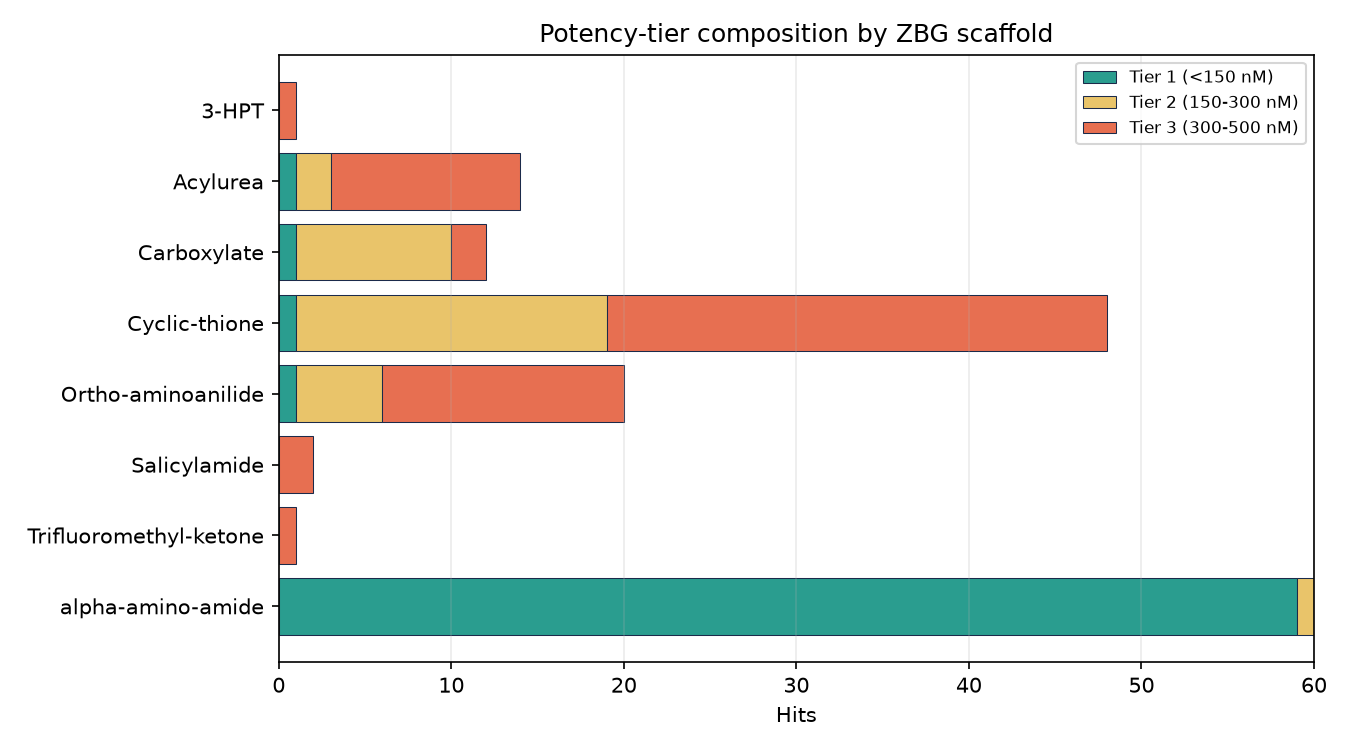

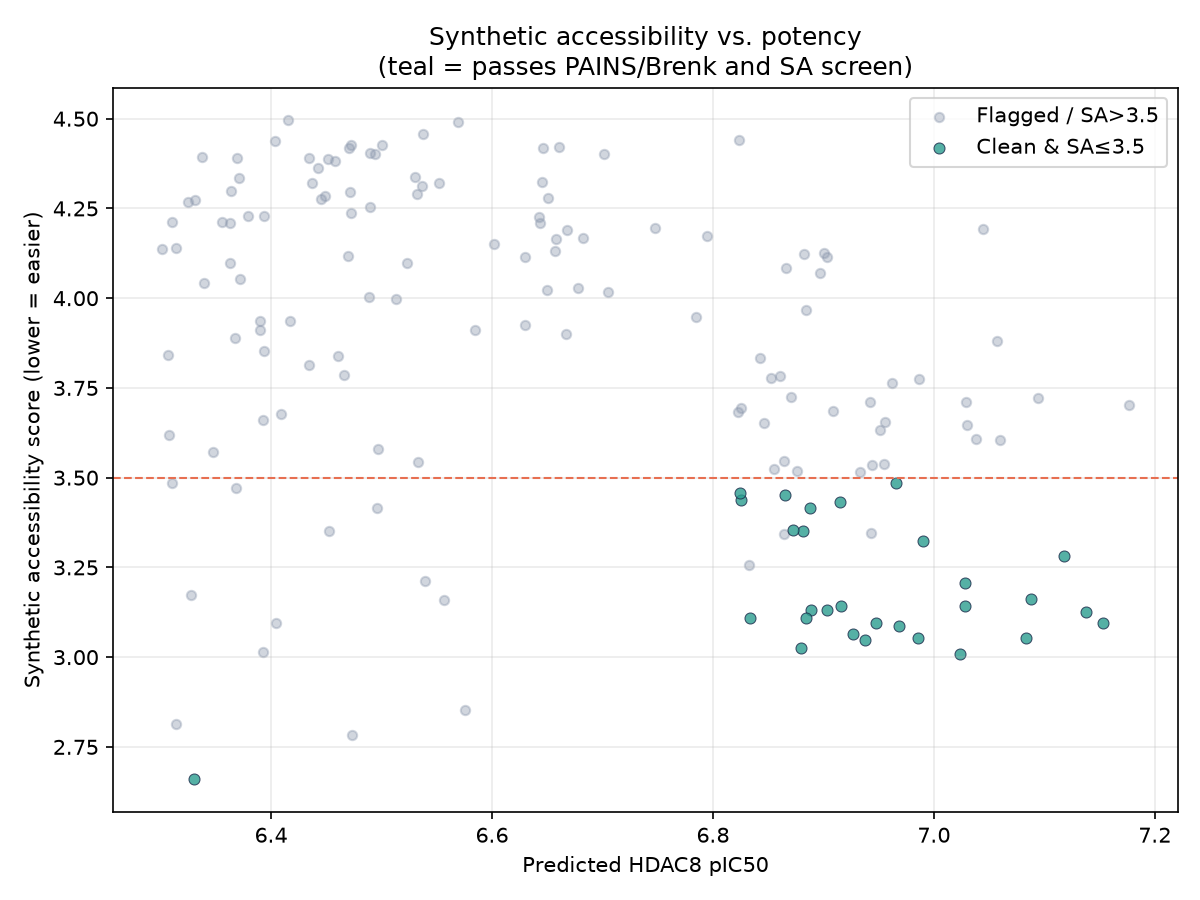

In [8]:
import make_figures
from IPython.display import Image, display

# Generate all nine figures from this mode's candidate CSVs + the shared model
# bundles in run_state.pkl. Figures land in ../figures/<RUN_MODE>/.
fig_names = make_figures.make_all_figures(
    cand_dir=CAND_DIR,
    models_dir=os.path.join('..', 'models'),
    fig_dir=FIG_DIR)
print(f"[{RUN_MODE}] Wrote:", fig_names)

# Display them inline in order.
fig_files = [
    'fig1_model_performance.png', 'fig2_training_pic50_dist.png',
    'fig3_docking_selectivity_landscape.png', 'fig4_zbg_distribution.png',
    'fig5_docking_by_target.png', 'fig6_potency_vs_selectivity.png',
    'fig7_property_space.png', 'fig8_tier_by_scaffold.png', 'fig9_sa_vs_potency.png']
for fn in fig_files:
    display(Image(filename=os.path.join(FIG_DIR, fn)))

## 9. Top candidates

In [9]:
cols = ['SMILES','zbg_tag','pIC50_pred','IC50_nM_est','IC50_tier',
        'docking_pred','docking_hdac1_pred','docking_hdac6_pred','docking_selectivity',
        'sa_score','exceeds_real_precedent']
full_df.sort_values('docking_selectivity', ascending=False)[cols].head(15)


,SMILES,zbg_tag,pIC50_pred,IC50_nM_est,IC50_tier,docking_pred,docking_hdac1_pred,docking_hdac6_pred,docking_selectivity,sa_score,exceeds_real_precedent
77,NC1CC(C(=O)CO)N2C(=S)Sc3ccc(CO)c(-c4cc(CCCO)cc...,Cyclic-thione,6.651042,223.335818,Tier 2 (150-300 nM),-9.382950,-6.608549,-6.495985,2.774401,4.279834,False
134,NC1CC(N)N2C(=S)Sc3ccc(CO)c(-c4cc(CCCO)ccc4F)c3...,Cyclic-thione,6.379079,417.754598,Tier 3 (300-500 nM),-9.156732,-6.350164,-6.543460,2.613272,4.228505,False
72,NC1CC(O)N2C(=S)Sc3ccc(CO)c(-c4cc(CCCO)ccc4F)c3...,Cyclic-thione,6.668315,214.627479,Tier 2 (150-300 nM),-9.209919,-6.281965,-6.635108,2.574810,4.190105,False
90,N#CCCC1CC(N)N=C2c3c(ccc(CO)c3-c3cc(CCCO)ccc3F)...,Cyclic-thione,6.552005,280.540122,Tier 2 (150-300 nM),-9.026511,-6.026323,-6.510494,2.516016,4.320565,False
150,CC(=O)C1CC(N)N=C2c3c(ccc(CO)c3-c3cc(CCCC#N)ccc...,Cyclic-thione,6.325090,473.053358,Tier 3 (300-500 nM),-9.028874,-5.864217,-6.678226,2.350648,4.268145,False
109,CC(=O)C1CC(N)N=C2c3c(ccc(CO)c3-c3cc(CCC#N)ccc3...,Cyclic-thione,6.471209,337.902113,Tier 3 (300-500 nM),-9.212056,-6.816341,-6.909889,2.302167,4.295048,False
80,NCC(=O)C1CC(N)N=C2c3c(ccc(CO)c3-c3cc(CCCO)ccc3...,Cyclic-thione,6.645649,226.126187,Tier 2 (150-300 nM),-8.991815,-6.773638,-6.567988,2.218178,4.322711,False
69,CC(CO)C1CC(N)N=C2c3c(ccc(CO)c3-c3cccc(CO)c3)SC...,Cyclic-thione,6.701812,198.695407,Tier 2 (150-300 nM),-8.916549,-6.428790,-6.780151,2.136399,4.402698,False
56,CCc1cc(C(F)CC)c(C[C@@H](N)C(=O)N2Cc3ccc(C(=O)N...,alpha-amino-amide,6.846260,142.475430,Tier 1 (<150 nM),-8.597634,-5.852588,-6.517845,2.079789,3.652871,False
145,CCC1CC(N)N=C2c3c(ccc(CO)c3-c3cccc(N4CCOCC4)c3)...,Cyclic-thione,6.339454,457.662799,Tier 3 (300-500 nM),-8.339775,-6.324159,-6.191829,2.015616,4.042363,False


## 10. Predict from SMILES

Score any SMILES (or list of SMILES) against all 6 trained models. Returns HDAC8
on-target predictions, HDAC1/HDAC6 off-target predictions (both IC50 and docking),
selectivity metrics, docking-selectivity gate status, drug-likeness flags, and
applicability-domain confidence.


In [10]:
def predict_from_smiles(smiles_list, sort_by='pIC50_pred'):
    """Score a list of SMILES (or a single SMILES string) against every trained
    model and return one tidy DataFrame row per compound.

    Columns include:
      - identity:      SMILES, valid, zbg_tag
      - HDAC8:         pIC50_pred, IC50_nM_est, docking_pred
      - HDAC1:         pIC50_hdac1_pred, IC50_hdac1_nM_est, docking_hdac1_pred, selectivity_vs_hdac1
      - HDAC6:         pIC50_hdac6_pred, IC50_hdac6_nM_est, docking_hdac6_pred, selectivity_vs_hdac6
      - selectivity:   docking_selectivity, passes_dock_gate
      - safety:        passes_lipinski_veber, sa_score, is_hydroxamate, pains_brenk_flagged,
                       hard_metabolic_liability, soft_metabolic_liability, hydrazide_liability,
                       nn_liability, passes_tier1_gates, tier1_fail_reason
      - confidence:    ic50_model_max_similarity, ic50_model_low_confidence, ic50_model_ad_reject,
                       dock_model_max_similarity, dock_model_low_confidence, dock_model_ad_reject

    Positive selectivity_vs_hdac1/6 = predicted to hit HDAC8 harder than that off-target.
    Positive docking_selectivity = HDAC8 docks stronger than both off-targets.
    passes_dock_gate = HDAC8 dock <= -7 and both off-target docks > -7.
    """
    if isinstance(smiles_list, str):
        smiles_list = [smiles_list]

    results = predict_batch(
        smiles_list, ic50_bundle, dock_bundle,
        hdac1_bundle=hdac1_bundle, hdac6_bundle=hdac6_bundle,
        hdac1_dock_bundle=hdac1_dock_bundle, hdac6_dock_bundle=hdac6_dock_bundle,
    )
    df = pd.DataFrame(results)

    # Add docking-selectivity gate flag
    def gate_row(row):
        d8 = row.get('docking_pred')
        d1 = row.get('docking_hdac1_pred')
        d6 = row.get('docking_hdac6_pred')
        if d8 is None or pd.isna(d8): return None
        return passes_docking_selectivity_gate(d8, d1, d6)
    df['passes_dock_gate'] = df.apply(gate_row, axis=1)

    column_order = [
        'SMILES', 'valid', 'zbg_tag',
        'pIC50_pred', 'IC50_nM_est', 'docking_pred',
        'pIC50_hdac1_pred', 'IC50_hdac1_nM_est', 'docking_hdac1_pred', 'selectivity_vs_hdac1',
        'pIC50_hdac6_pred', 'IC50_hdac6_nM_est', 'docking_hdac6_pred', 'selectivity_vs_hdac6',
        'docking_selectivity', 'passes_dock_gate',
        'passes_lipinski_veber', 'sa_score', 'is_hydroxamate', 'pains_brenk_flagged',
        'hard_metabolic_liability', 'soft_metabolic_liability', 'hydrazide_liability', 'nn_liability',
        'passes_tier1_gates', 'tier1_fail_reason',
        'ic50_model_max_similarity', 'ic50_model_low_confidence', 'ic50_model_ad_reject',
        'dock_model_max_similarity', 'dock_model_low_confidence', 'dock_model_ad_reject',
    ]
    df = df[[c for c in column_order if c in df.columns]]
    if sort_by and sort_by in df.columns and df['valid'].any():
        df = df.sort_values(sort_by, ascending=False, na_position='last').reset_index(drop=True)
    return df

print("predict_from_smiles() defined — pass any SMILES or list of SMILES.")


predict_from_smiles() defined — pass any SMILES or list of SMILES.


### Example usage

Swap in your own SMILES below. Works for one compound or a batch.

In [11]:
# Score two balanced-deliverable hits + vorinostat/SAHA (hydroxamate → Tier-1 rejection)
example_smiles = list(balanced['SMILES'].head(2)) + ['ONC(=O)/C=C/c1ccc(CNC(=O)c2ccccc2)cc1']
predict_from_smiles(example_smiles)


,SMILES,valid,zbg_tag,pIC50_pred,IC50_nM_est,docking_pred,pIC50_hdac1_pred,IC50_hdac1_nM_est,docking_hdac1_pred,selectivity_vs_hdac1,...,hydrazide_liability,nn_liability,passes_tier1_gates,tier1_fail_reason,ic50_model_max_similarity,ic50_model_low_confidence,ic50_model_ad_reject,dock_model_max_similarity,dock_model_low_confidence,dock_model_ad_reject
0,CC(C)COCC(CO)C(OCC1C(=O)NC(=O)NC1=O)c1ccoc1,True,Acylurea,6.903290,124.942509,-7.334063,6.084650,822.906493,-6.378675,0.818640,...,False,False,True,NaN,0.206186,True,False,0.280000,True,False
1,ONC(=O)/C=C/c1ccc(CNC(=O)c2ccccc2)cc1,True,Unknown,6.656634,220.478219,-7.689213,7.023374,94.760272,-7.224687,-0.366739,...,False,False,False,hydroxamate,0.727273,False,False,0.560976,False,False
2,CCC(CN)(CC(C(O)OC)n1cccc(O)c1=S)c1ccnc(N2CCOCC...,True,3-HPT,6.436848,365.722379,-7.135647,5.686887,2056.426594,-6.590240,0.749962,...,False,False,True,NaN,0.250000,True,False,0.271739,True,False


## 11. Save run state

Stores the four result dataframes in this mode's slot so they reload without re-running the GA.

Only for the `REGENERATE = False` path, where you have loaded a cached mode and adjusted something by hand. Any regenerate already saved every mode it ran, inside `## 5`, so this cell skips itself rather than writing a second entry for the same run.

In [12]:
# Updates only this mode's slot in the shared pickle; results already stored for
# the other modes are left alone. Written via a temp file and moved into place,
# so an interrupted save cannot destroy the other modes' results.
#
# Model bundles are not stored here. They are identical across all three modes
# (no mode retrains anything) and already live in ../models/run_state.pkl, which
# is where make_figures.py reads them from.
#
# Guarded: assemble_and_export in ## 5 saves each mode it regenerates, so running
# this after a regenerate would write a second entry with a fresh saved_at for the
# same results.
if _regenerated:
    print(f"Skipped: ## 5 already saved every mode it regenerated ('{RUN_MODE}' last). "
          f"This cell is for re-saving a cached mode you have adjusted by hand.")
else:
    _state = save_mode_run_state(RUN_MODE, full_df, balanced, reps, final_screen)
    print(f"Updated {os.path.basename(RUN_STATE_PKL)} slot '{RUN_MODE}'.")
    print("Modes now stored:", {m: f"{len(_state[m]['hits_df'])} hits" for m in sorted(_state)})


Skipped: ## 5 already saved every mode it regenerated ('integrated' last). This cell is for re-saving a cached mode you have adjusted by hand.
